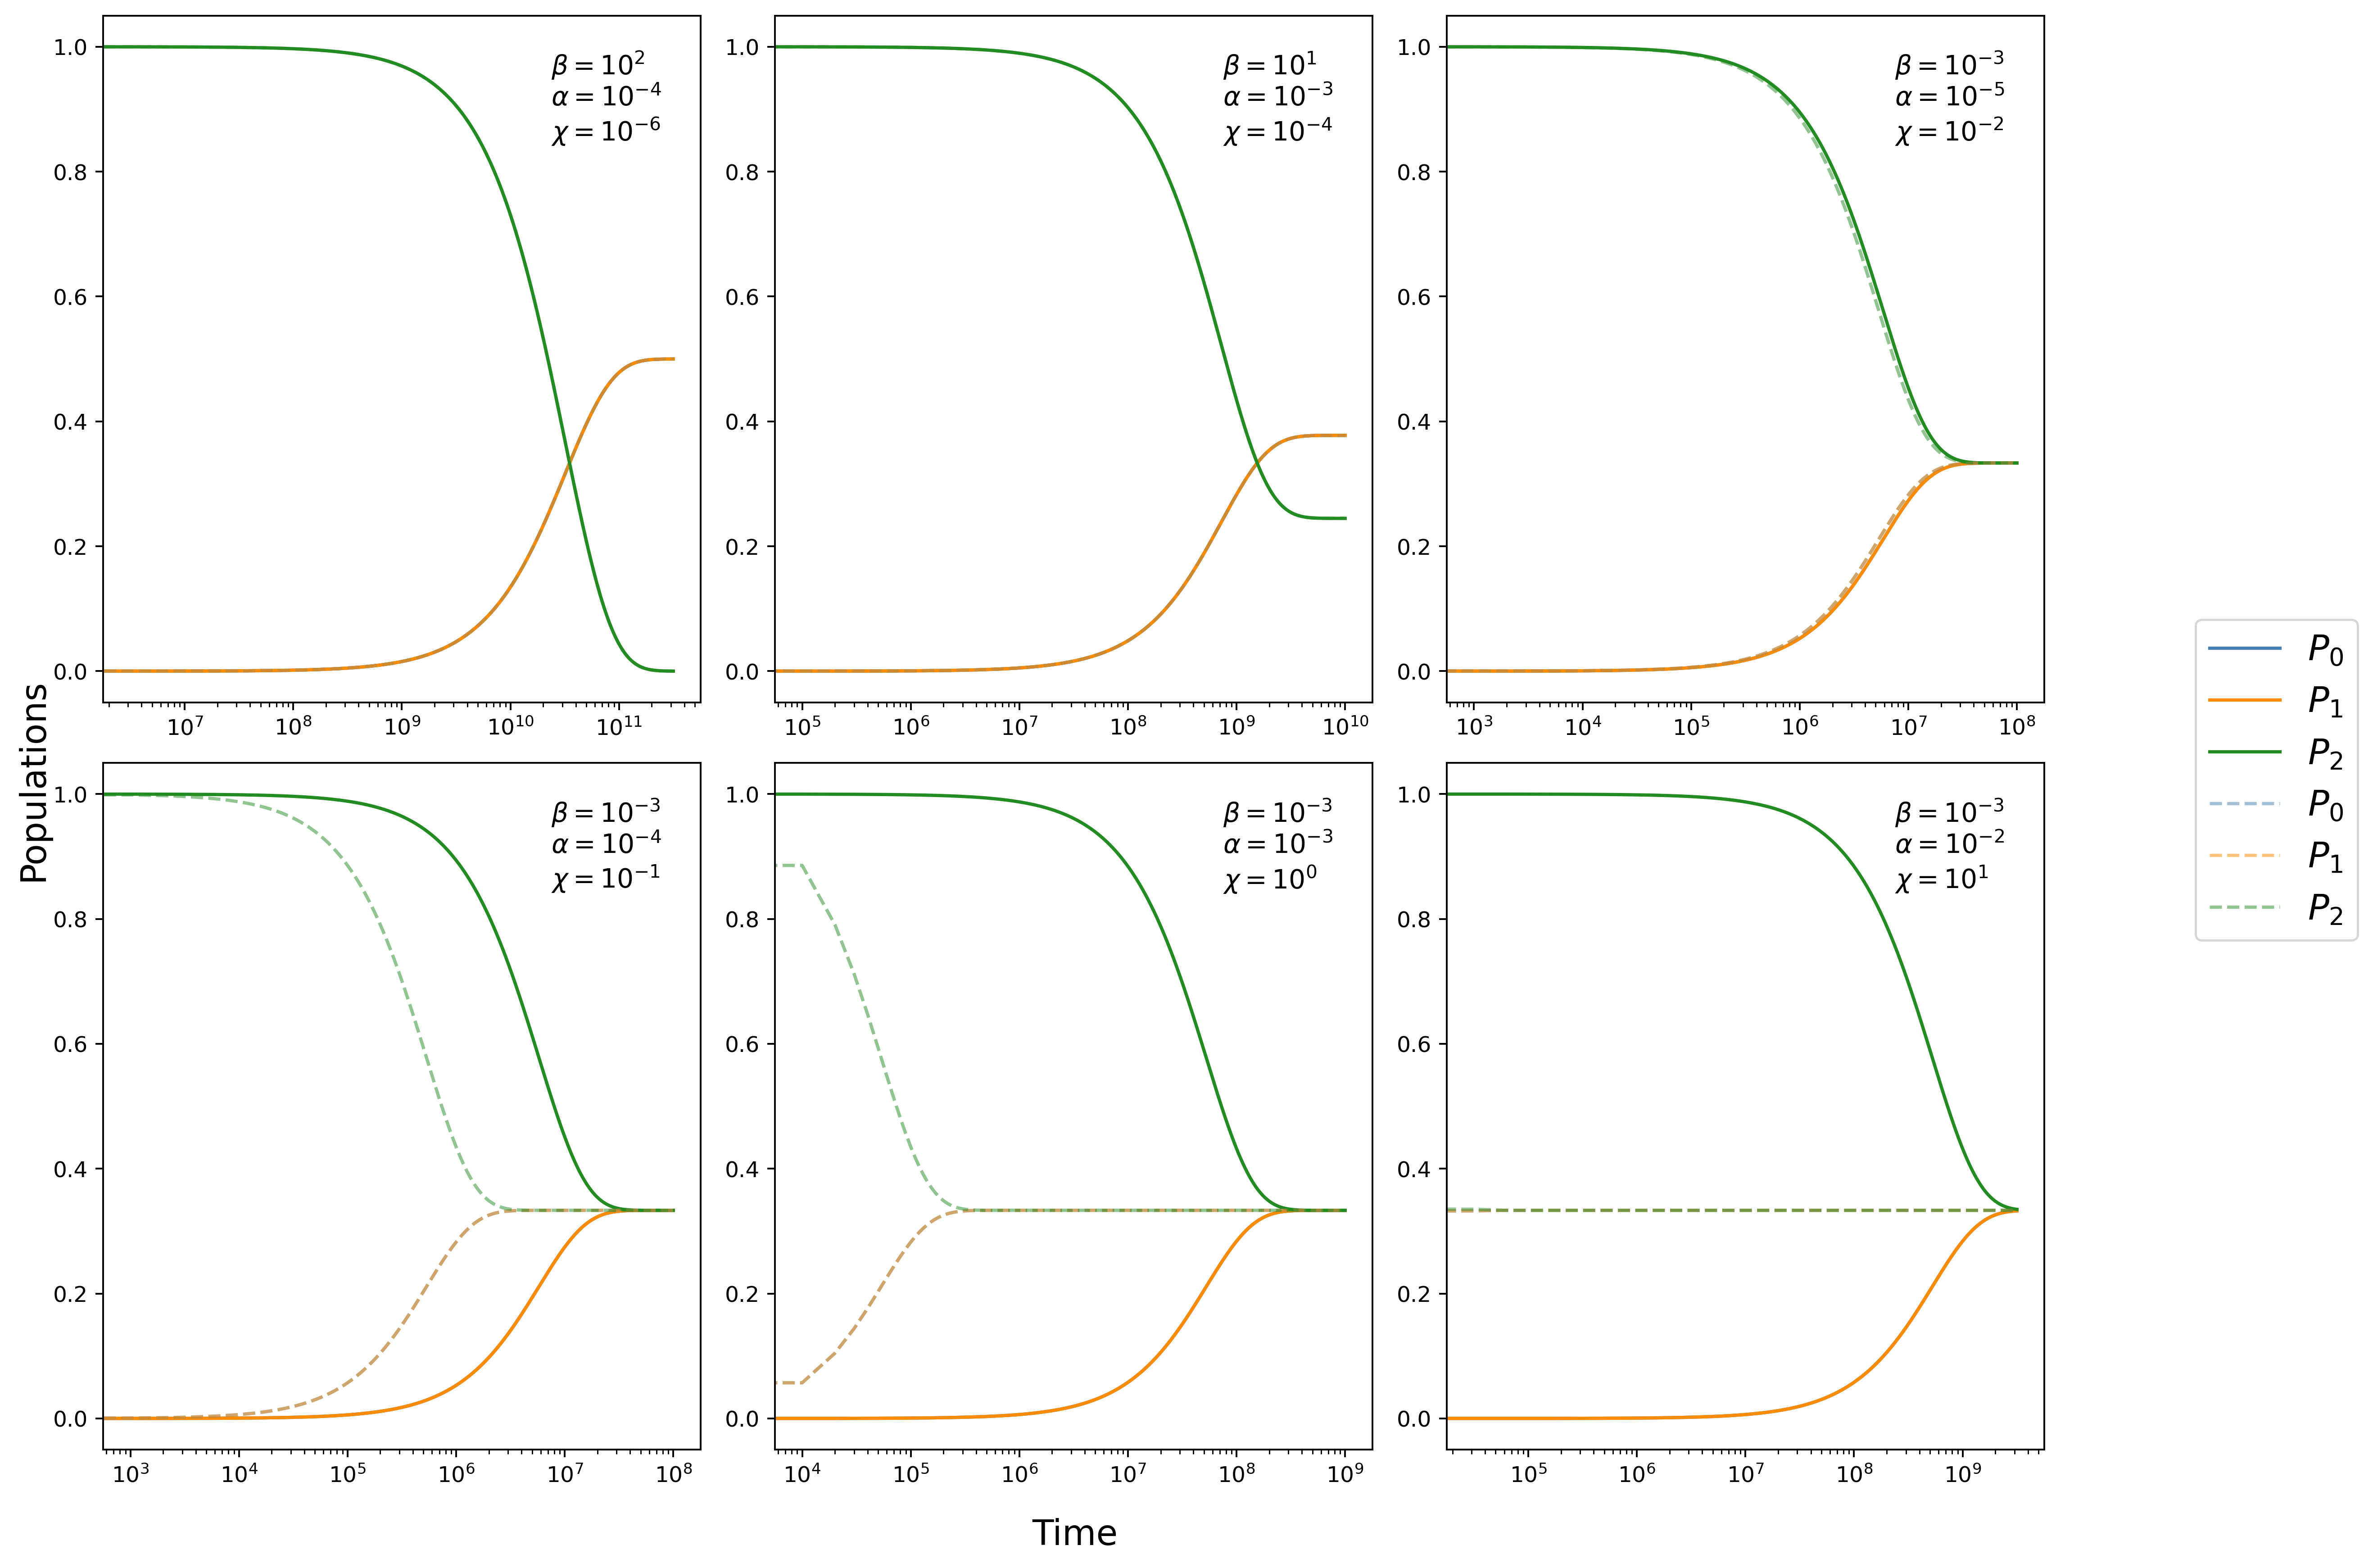

In [1]:
%matplotlib inline
import numpy as np
from utils import _build_redfield_numba, build_redfield_tensor, evolve_density_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams['figure.dpi']=350

#coupling params
J = 0.1
eps = 1e-4 
Eps=1e-4
Alpha=1e-6
Beta=10
Omega_c=50

#bath params- assuming 3 decoupled ohmic baths
wc_list=np.array(Omega_c*np.ones(3))


Betas=np.array([10**2,10,10**(-3),
               10**(-3),10**(-3),10**(-3)])
Alphas=np.array([10**(-4),10**(-3),10**(-5),
                10**(-4),10**(-3),10**(-2)])
endpts=np.array([10**11.5,10**10,10**8,
                10**8,10**9,10**9.5])

H=np.array([[0,J,eps],
            [J,0,Eps],
            [eps,Eps,0]
           ])
#plot spectrum
        
#system-bath coupling operators 
S_list=[]
for i in range(H.shape[0]):
    S=np.zeros((H.shape[0],H.shape[0]))
    S[i,i]=1
    S_list.append(S)
def dens(alpha, wc, x): #J(w) spectral density function for baths
    return 2 * alpha * x * np.exp(-x / wc)

def eta(beta, x):  #the thermal factor
    return 1 / np.expm1(beta * x)  # better than exp(beta*x)-1 near x=0

def evolve_function(B,A,endpt):
    beta_list=np.array(B*np.ones(3))
    alpha_list=np.array(A*np.ones(3))
    def gamma_func(w): #Laplace transforms of bath correlation functions 
        gammas = []
        absw = abs(w)
        for alpha, wc, beta in zip(alpha_list, wc_list, beta_list):

            if absw < 1e-12:
                # Ohmic zero-frequency limit:
                # dens(alpha,wc,w) * eta(beta,w) -> 2 alpha / beta
                g = (np.pi/2)*(alpha/beta)
            elif w > 0:
                g = (np.pi/4)*dens(alpha,wc,absw)*(eta(beta,absw)+1) #ignoring the complex part with the Cauchy PV dist.
            else:
                g = (np.pi/4)*dens(alpha,wc,absw)*eta(beta,absw)
            gammas.append(g + 0j) #ensures dtype is complex with 0 complex part

        return np.array(gammas, dtype=np.complex128)

    R,U=build_redfield_tensor(H,S_list,gamma_func, False,1e-10,True) 

    COB=np.array([
        [1,0,0,0,0,0,0,0,0],
        [0,0,0,0,1,0,0,0,0],
        [0,0,0,0,0,0,0,0,1],
        [0,1,0,0,0,0,0,0,0],
        [0,0,1,0,0,0,0,0,0],
        [0,0,0,1,0,0,0,0,0],
        [0,0,0,0,0,1,0,0,0],
        [0,0,0,0,0,0,1,0,0],
        [0,0,0,0,0,0,0,1,0]])
    Rprime=COB@R@COB.T #in new block basis
    for i in range(9):
        for j in range(9):
            if i>2 and j<=2 or i<=2 and j>2:
                Rprime[i,j]=0

    R_altered=COB.T@Rprime@COB # convert back to energy basis
    #initial condition and time array
    rho_init=np.zeros((3,3))
    rho_init[2,2]=1   #initial density matrix in local basis - state |A><A|
    time_steps=np.linspace(0,endpt,1*(10**5))

    #time eveolve
    rho_t=evolve_density_matrix(R, time_steps, rho_init, U, n_jobs=-1, energy_basis=False)
    rho_t=np.array(rho_t)

    rho_t_altered=evolve_density_matrix(R_altered, time_steps, rho_init, U, n_jobs=-1, energy_basis=False)
    rho_t_altered=np.array(rho_t_altered)

    #populations in each site
    populations=[]
    for k in range(H.shape[0]):
        populations.append(rho_t[:,k,k].real)
    populations=np.array(populations)
    
    populations_altered=[]
    for k in range(H.shape[0]):
        populations_altered.append(rho_t_altered[:,k,k].real)
    populations_altered=np.array(populations_altered)
    return populations, populations_altered, time_steps

colours=['steelblue','darkorange','forestgreen']

fig,axes=plt.subplots(2,3,figsize=(14,10))

for j,(B,A, endpt) in enumerate(zip(Betas,Alphas,endpts)): 
    a=j//3
    b=j%3
    populations,populations_altered,time_steps=evolve_function(B,A,endpt)
    for k in range(H.shape[0]):
        axes[a,b].plot(time_steps,populations[k,:],color=colours[k],label=f'$P_{k}$')
    for k in range(H.shape[0]):
        axes[a,b].plot(time_steps,populations_altered[k,:],color=colours[k],alpha=0.5,ls='--',label=f'$P_{k}$')
    axes[a,b].set_xscale('log')
    expB = int(np.log10(B))
    expA= int(np.log10(A))
    expChi=int(np.log10(A/B))
    
    axes[a,b].text(0.75, 0.95, f'$\\beta=10^{{{expB}}}$\n$\\alpha=10^{{{expA}}}$\n$\\chi=10^{{{expChi}}}$', transform=axes[a,b].transAxes, 
            fontsize=12, verticalalignment='top')

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles,labels,loc='center left',bbox_to_anchor=(1, 0.5),fontsize=16)
fig.supxlabel('Time',fontsize=16)
fig.supylabel('Populations',fontsize=16)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()    
    


